# Notebook 2 — Preprocessing

*SWC ENC 2026 · ephys-pop module*

The raw voltage is a mess of nuisances that bury the spikes. Before we detect
anything we clean it up, following Kilosort's preprocessing: **three problems, three
tools**.

| nuisance | what it is | tool |
|---|---|---|
| slow drift / LFP | low-frequency signal shared across channels | **high-pass filter** |
| shared artefact | a fast signal identical on every channel (movement, reference) | **common average reference** |
| correlated noise | nearby channels share noise, so a threshold means different things on different channels | **whitening** |

The first tool, **filtering**, works in the language of *frequency* — so we'll start
by building that language up from scratch, then use it. By the end you will have:

1. seen a signal as a mix of **frequencies** (the Fourier view and the power spectrum),
2. understood what a **filter** does, and what a **Butterworth** filter is,
3. **high-pass filtered** the recording, **common-average-referenced** it, and
   **whitened** it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import picosort as ps

rec = ps.make_recording(n_units=6, duration_s=20.0, seed=0)
raw = rec.traces
print("raw traces:", raw.shape)

raw traces: (600000, 32)


## 1. A signal is a mixture of frequencies

A voltage trace looks like a squiggle in *time*. But there's a second, equally valid
way to describe it: by *what frequencies it is made of* — how much slow wave, how much
fast wiggle. This **frequency view** is the whole key to separating spikes (fast)
from drift (slow).

To see it, let's build a signal by hand out of three pure sine waves — a slow 4 Hz
wave, a medium 40 Hz wave, and a fast 200 Hz wave — and add them up.

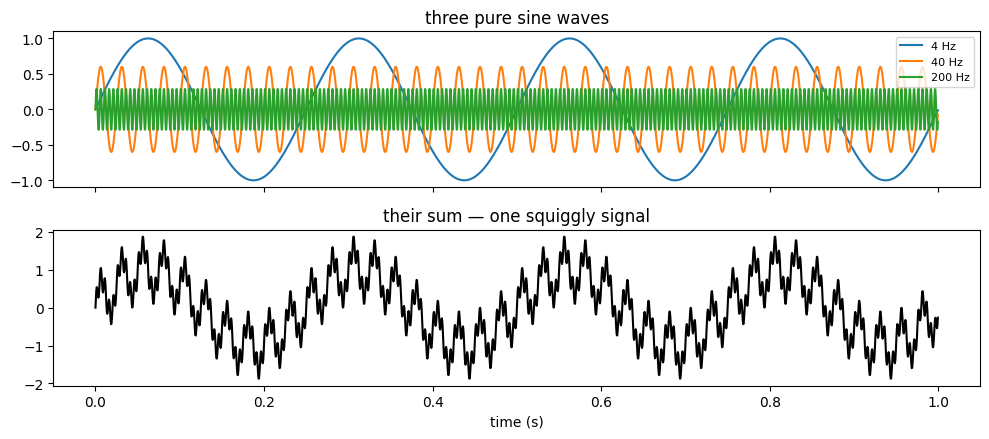

In [2]:
fs_demo = 2000.0                     # samples per second, for this toy example
t = np.arange(0, 1.0, 1 / fs_demo)   # one second
slow  = 1.0 * np.sin(2 * np.pi * 4   * t)
med   = 0.6 * np.sin(2 * np.pi * 40  * t)
fast  = 0.3 * np.sin(2 * np.pi * 200 * t)
signal = slow + med + fast

fig, ax = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)
ax[0].plot(t, slow, label="4 Hz"); ax[0].plot(t, med, label="40 Hz"); ax[0].plot(t, fast, label="200 Hz")
ax[0].set_title("three pure sine waves"); ax[0].legend(loc="upper right", fontsize=8)
ax[1].plot(t, signal, color="k"); ax[1].set_title("their sum — one squiggly signal")
ax[1].set_xlabel("time (s)"); plt.tight_layout(); plt.show()

The sum (bottom) is a single wiggly trace. If someone handed you just that, could you
recover the three ingredients? Yes — with the **Fourier transform**.

The idea is simple: to ask "how much 40 Hz is in this signal?", you **compare the
signal to a 40 Hz sine wave** — multiply them point by point and add up. If the signal
contains a 40 Hz component, the two line up and the sum is large; if it doesn't, the
pluses and minuses cancel and the sum is near zero. Do this for *every* frequency and
you get a recipe listing how much of each frequency is present. The **power spectrum**
is that recipe, plotted: power (how much) versus frequency.

<details>
<summary><b>▸ Go deeper: the Fourier transform as an equation (optional)</b></summary>

"Compare the signal to a sine wave of each frequency and add up" is, written out, the
**discrete Fourier transform**. For samples $x_0,\dots,x_{N-1}$, the amount of
frequency index $k$ is

$$X_k \;=\; \sum_{n=0}^{N-1} x_n\, e^{-2\pi i\, k n / N}.$$

The wiggling factor is just a sine and cosine bundled together, since
$e^{-2\pi i\,kn/N} = \cos(2\pi kn/N) - i\,\sin(2\pi kn/N)$. So multiplying $x_n$ by it
and summing *is* the "compare and add up" from above — done against a cosine and a
sine at once. The result $X_k$ is a complex number: its magnitude $|X_k|$ says how
much of that frequency is present, its angle says the phase. Frequency index $k$
corresponds to $k\,f_s/N$ hertz, and the **power spectrum** is $|X_k|^2$ — exactly
`np.abs(np.fft.rfft(x))**2`. (`rfft` is the fast $O(N\log N)$ algorithm for this sum,
returning just the non-negative frequencies.)
</details>

**Exercise 1** *(~4 min · easy)*. Complete `power_spectrum`: use `np.fft.rfft` to get the
frequency content and `np.fft.rfftfreq` for the matching frequency axis; power is the
squared magnitude `np.abs(...)**2`.

> **Check / unstuck.** You should see three sharp peaks, at **4, 40, and 200 Hz** —
> exactly the waves we added. Stuck? the frequencies are `np.fft.rfftfreq(len(x), 1/fs)`
> and the power is `np.abs(np.fft.rfft(x))**2`.

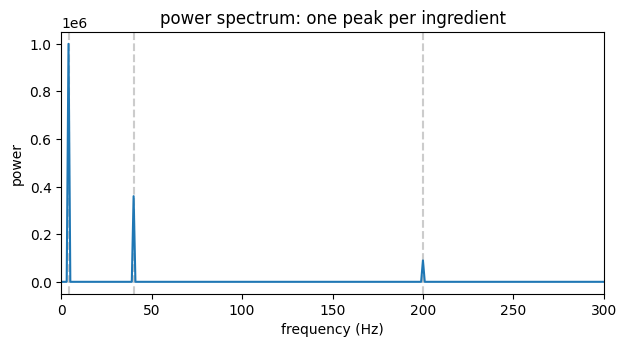

In [3]:
def power_spectrum(x, fs):
    spectrum = np.fft.rfft(x)                 # frequency content (complex)
    freqs = np.fft.rfftfreq(len(x), 1 / fs)   # the matching frequency axis (Hz)
    power = np.abs(spectrum) ** 2             # how much of each frequency
    return freqs, power

f, p = power_spectrum(signal, fs_demo)
plt.figure(figsize=(7, 3.4))
plt.plot(f, p); plt.xlim(0, 300)
for freq in (4, 40, 200):
    plt.axvline(freq, color="0.8", ls="--", zorder=0)
plt.xlabel("frequency (Hz)"); plt.ylabel("power")
plt.title("power spectrum: one peak per ingredient"); plt.show()

Three peaks, at exactly the three frequencies we put in. That's the power spectrum's
job: it reveals the hidden frequency ingredients of any signal. A real neural
recording has a spectrum too — lots of power at low frequencies (the slow drift and
LFP) and a broad spread at high frequencies where the spikes live.

## 2. Filtering: keep some frequencies, remove others

Once you can see a signal as a set of frequencies, **filtering** is the natural next
move: keep the frequencies you want and remove the ones you don't.

- a **low-pass** filter keeps *low* frequencies (slow waves) and removes high ones,
- a **high-pass** filter keeps *high* frequencies (fast wiggles) and removes low ones,
- a **band-pass** filter keeps a middle band.

Watch what each does to our three-ingredient signal. A **high-pass** at 100 Hz should
throw away the 4 Hz and 40 Hz waves and keep only the fast 200 Hz one; a **low-pass**
at 100 Hz should do the opposite.

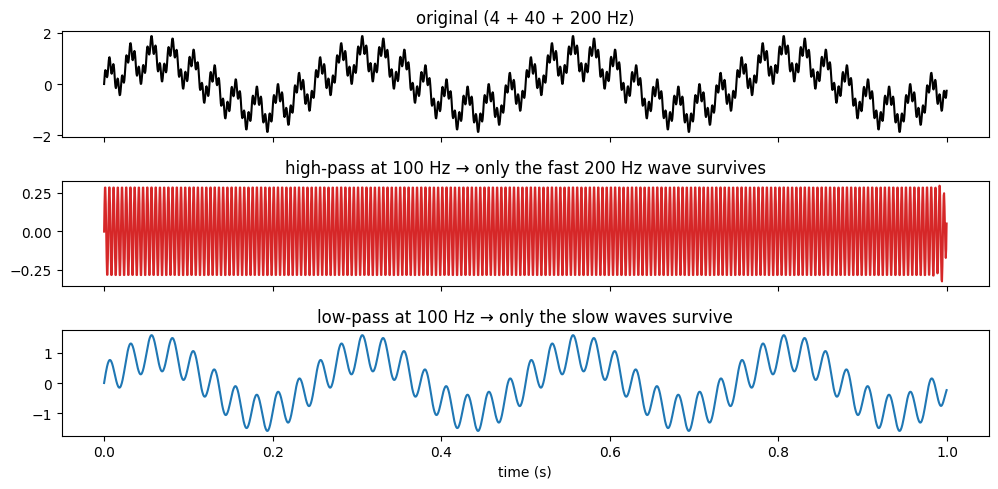

In [4]:
from scipy.signal import butter, filtfilt

def apply_filter(x, fs, cutoff, kind):
    b, a = butter(4, cutoff / (fs / 2), btype=kind)
    return filtfilt(b, a, x)

hp = apply_filter(signal, fs_demo, 100, "high")   # keep fast
lp = apply_filter(signal, fs_demo, 100, "low")    # keep slow

fig, ax = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
ax[0].plot(t, signal, "k"); ax[0].set_title("original (4 + 40 + 200 Hz)")
ax[1].plot(t, hp, "tab:red"); ax[1].set_title("high-pass at 100 Hz → only the fast 200 Hz wave survives")
ax[2].plot(t, lp, "tab:blue"); ax[2].set_title("low-pass at 100 Hz → only the slow waves survive")
ax[2].set_xlabel("time (s)"); plt.tight_layout(); plt.show()

Exactly as advertised: the high-pass output is a clean 200 Hz wiggle (the slow waves
are gone), and the low-pass output is the slow rolling wave (the fast wiggle is gone).
Filtering let us *pull apart* components that were added together — which is precisely
what we need, because spikes and drift live at different frequencies.

## 3. What is a Butterworth filter?

We asked for a "high-pass at 100 Hz", but a real filter can't switch instantly from
"keep" to "remove" at exactly 100 Hz — that ideal brick wall is impossible. Every
practical filter has a smooth transition, and different **filter designs** make
different trade-offs. The **Butterworth** filter is the standard workhorse: it is
*maximally flat* in the band it keeps (so it doesn't distort those frequencies), at
the cost of a gently sloping transition.

Two dials control it: the **cutoff frequency** (where it switches from keep to
remove) and the **order** (how *sharply* it makes that switch). The picture below is
a filter's **frequency response** — the gain (0 = block, 1 = pass) it applies at each
frequency. Higher order = steeper cliff at the cutoff.

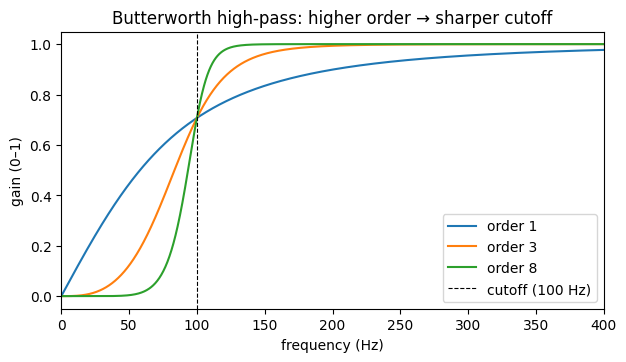

In [5]:
from scipy.signal import freqz

plt.figure(figsize=(7, 3.6))
for order in (1, 3, 8):
    b, a = butter(order, 100 / (fs_demo / 2), btype="high")
    w, h = freqz(b, a, worN=4000, fs=fs_demo)
    plt.plot(w, np.abs(h), label=f"order {order}")
plt.axvline(100, color="k", ls="--", lw=0.8, label="cutoff (100 Hz)")
plt.xlim(0, 400); plt.xlabel("frequency (Hz)"); plt.ylabel("gain (0–1)")
plt.title("Butterworth high-pass: higher order → sharper cutoff"); plt.legend(); plt.show()

Below the cutoff the gain is near 0 (those frequencies are removed); above it the gain
is near 1 (kept). A low order rolls off gently; a high order approaches the ideal
brick wall but can introduce other artefacts, so a **middle order (3–4) is the usual
choice** — flat where it matters, sharp enough, well-behaved. That's what we'll use.

<details>
<summary><b>▸ Go deeper: the Butterworth response equation (optional)</b></summary>

Those S-curves have a one-line formula. A Butterworth filter of order $n$ with cutoff
$f_c$ has squared gain (low-pass form)

$$|H(f)|^2 \;=\; \frac{1}{1 + (f/f_c)^{2n}}.$$

Read off the behaviour: at $f = f_c$ the denominator is $2$, so the gain is
$1/\sqrt{2} \approx 0.707$ **for every order** — that's the $-3$ dB point where all the
curves crossed. As $n$ grows, $(f/f_c)^{2n}$ flips from $\approx 0$ to $\gg 1$ ever
more abruptly around $f_c$, sharpening the transition toward the ideal brick wall. And
"maximally flat" is precise: this $|H|^2$ has the most possible derivatives equal to
zero at $f=0$, so the passband is as ripple-free as any filter of that order can be.
(The high-pass we actually use is the same with $f$ and $f_c$ swapped,
$|H|^2 = 1/(1+(f_c/f)^{2n})$.)
</details>

## 4. High-pass the recording

Now the real thing. In an extracellular recording the **spikes are fast** (their
energy sits above a few hundred Hz) while the **drift and LFP are slow** (below).
So a high-pass filter at **300 Hz** — the standard cutoff for the Neuropixels AP band
— keeps the spikes and removes the slow stuff. Here's the power spectrum of one real
channel before and after:

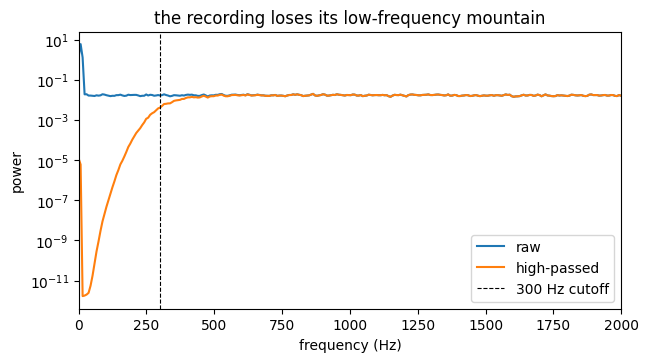

In [6]:
from scipy.signal import welch

filt_hp = ps.highpass_filter(raw, rec.fs, cutoff=300)

f, praw = welch(raw[:, 10], fs=rec.fs, nperseg=4096)
f, php = welch(filt_hp[:, 10], fs=rec.fs, nperseg=4096)
plt.figure(figsize=(7, 3.6))
plt.semilogy(f, praw, label="raw")
plt.semilogy(f, php, label="high-passed")
plt.axvline(300, color="k", ls="--", lw=0.8, label="300 Hz cutoff")
plt.xlim(0, 2000); plt.xlabel("frequency (Hz)"); plt.ylabel("power")
plt.legend(); plt.title("the recording loses its low-frequency mountain"); plt.show()

(`welch` is just a smoothed power spectrum — the same idea as Exercise 1, averaged
over short windows to reduce noise.) The huge low-frequency mountain — the drift and
LFP — is gone, and the fast content where spikes live is untouched.

## 5. Common average reference

Some artefacts appear *identically* on every channel — a movement, a reference
fluctuation. Because they're the same everywhere, we can estimate them by the
**across-channel average** at each moment and subtract it. We use the **median**
rather than the mean so that a big spike on one channel can't drag the reference.

**Exercise 2** *(~3 min · easy)*. Complete `common_average_reference`: subtract the median
across channels (axis 1) at every time sample.

> **Check / unstuck.** After CAR the per-sample median across channels should be ~0.
> Stuck? Use `ps.common_average_reference(filt_hp)`.

In [7]:
def common_average_reference(traces):
    return traces - np.median(traces, axis=1, keepdims=True)

filt = common_average_reference(filt_hp)
print("median across channels before CAR:", np.median(np.abs(np.median(filt_hp, axis=1))).round(2))
print("median across channels after  CAR:", np.median(np.abs(np.median(filt, axis=1))).round(4))

median across channels before CAR: 7.15


median across channels after  CAR: 0.0


## 6. Whitening

One nuisance remains, and it's the subtle one. The background noise is **spatially
correlated**: nearby channels tend to wiggle together. Look at the **noise
covariance** — a grid showing how much each pair of channels moves together. Bright
means "these two channels are correlated." There's an obvious bright band along the
diagonal, meaning neighbours are correlated.

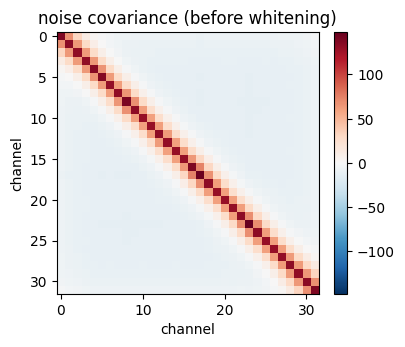

In [8]:
cov = ps.noise_covariance(filt)
ps.plotting.plot_covariance(cov, title="noise covariance (before whitening)")
plt.show()

Correlated noise is a problem for detection: a fluctuation shared by five neighbouring
channels can masquerade as a big multi-channel event, and a threshold of "5 sigma"
then means different things on different channels. **Whitening** removes these
correlations. It applies a linear transform that leaves each channel with equal
variance and *zero* correlation to its neighbours — so afterwards the noise is
spatially flat and a single threshold is meaningful everywhere.

The recipe: measure the noise covariance, then apply the transform that "divides it
out." Concretely we use $W = C^{-1/2}$ (the matrix square root of the inverse
covariance), which is the gentlest transform that flattens the correlations while
keeping the channels in place.

**Exercise 3** *(~7 min · meaty)*. Complete `whitening_matrix`. The steps are given —
eigen-decompose the covariance, then rescale each eigen-direction by
$1/\sqrt{\text{eigenvalue}}$. Then we apply it and check the covariance is now clean.

> **Check / unstuck.** After whitening, the covariance grid should be a bright
> diagonal with near-zero (blank) off-diagonal. Stuck? Use `ps.whitening_matrix(cov)`.

<details>
<summary><b>▸ Go deeper: the whitening matrix, in symbols (optional)</b></summary>

Write the noise across channels at one instant as a vector $n$ with covariance
$C = \mathbb{E}[n\,n^{\top}]$ (the grid you just plotted). We want a linear map $W$ so
the transformed noise $z = Wn$ has covariance equal to the identity — unit variance on
every channel, zero correlation between them:

$$\mathrm{Cov}(z) = \mathbb{E}[Wn\,n^{\top}W^{\top}] = W\,C\,W^{\top} = I.$$

Because $C$ is symmetric it has an **eigen-decomposition** $C = V\Lambda V^{\top}$: the
columns of $V$ are perpendicular eigen-directions and $\Lambda$ holds the noise
variance along each. Taking the symmetric square root

$$W = C^{-1/2} = V\,\Lambda^{-1/2}\,V^{\top}$$

does the job, since $W C W^{\top} = V\Lambda^{-1/2}V^{\top}\,V\Lambda V^{\top}\,
V\Lambda^{-1/2}V^{\top} = V\Lambda^{-1/2}\Lambda\Lambda^{-1/2}V^{\top} = VV^{\top} = I.$
In words that's "**rotate** onto the eigen-axes ($V^{\top}$), **rescale** each to unit
variance ($\Lambda^{-1/2}$), **rotate back** ($V$)" — which is what `np.linalg.eigh`
plus the $1/\sqrt{\lambda}$ rescaling build. Any rotation of $W$ also whitens; this
symmetric choice (**ZCA**) is the one closest to the identity, so channels stay in
place. The $\epsilon$ floors tiny eigenvalues, since $1/\sqrt{\lambda}$ would otherwise
explode along near-zero-variance directions.

This connects forward to **Notebook 6**: the statistically optimal detector for a
template $s$ in noise of covariance $C$ is $s^{\top}C^{-1}x$; whitening the data first
turns that into a plain template match, getting the optimal detector for free.
</details>

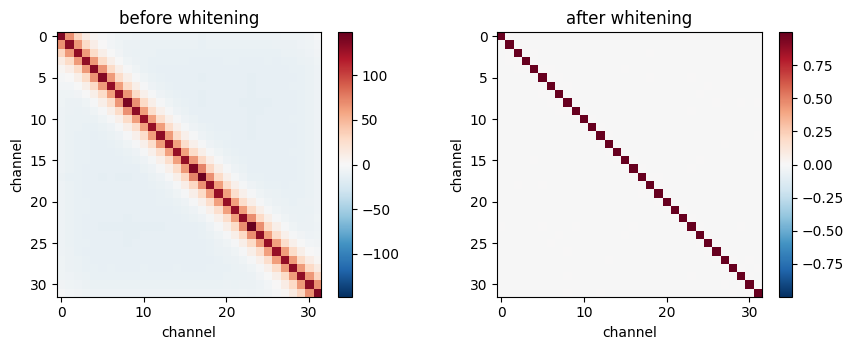

mean |off-diagonal| before: 13.684
mean |off-diagonal| after : 0.0


In [9]:
def whitening_matrix(cov, eps=1e-6):
    vals, vecs = np.linalg.eigh(cov)          # eigenvalues (variances) and directions
    reg = eps * vals.max()                     # floor tiny eigenvalues
    return vecs @ np.diag(1.0 / np.sqrt(vals + reg)) @ vecs.T

W = whitening_matrix(cov)
whitened = filt @ W
cov_after = ps.noise_covariance(whitened)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
ps.plotting.plot_covariance(cov, ax=axes[0], title="before whitening")
ps.plotting.plot_covariance(cov_after, ax=axes[1], title="after whitening")
plt.tight_layout(); plt.show()
print("mean |off-diagonal| before:", round(np.abs(cov - np.diag(np.diag(cov))).mean(), 3))
print("mean |off-diagonal| after :", round(np.abs(cov_after - np.diag(np.diag(cov_after))).mean(), 3))

The off-diagonal correlations collapse: whitened noise is spatially flat, so a
detection threshold means the same thing on every channel.

## Putting it together

The whole pipeline — high-pass → CAR → whiten — is `ps.preprocess`. It returns two
things we'll both use: the **whitened** traces (for *detecting* spikes, where a
uniform threshold is what we want) and the **filtered** traces (high-passed and
CAR'd but not whitened, in real microvolts, where a spike's spatial footprint is
undistorted — the right place to *measure* waveforms and build templates).

whitened: (600000, 32)  filtered: (600000, 32)


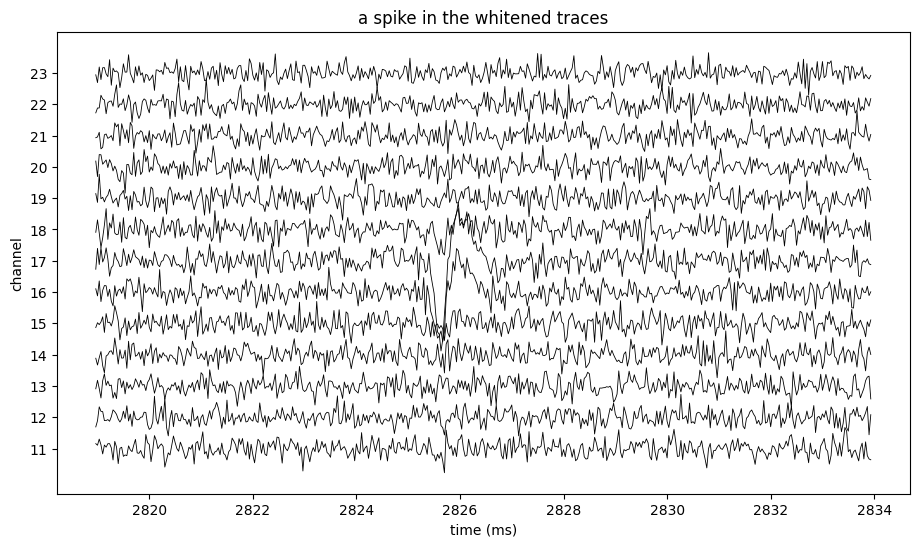

In [10]:
whitened, filtered, W = ps.preprocess(rec)
print("whitened:", whitened.shape, " filtered:", filtered.shape)

# The same spike, now clearly above the flat whitened noise.
gt = rec.ground_truth
u = int(np.argmax(gt.unit_amplitude)); t = gt.spike_times[gt.spike_labels == u][5]
pc = ps.peak_channel(gt.templates[u]); lo = max(0, pc - 6)
ps.plotting.plot_signal(whitened, rec.fs, channels=range(lo, lo + 13),
                        t0=(t - 200) / rec.fs, t1=(t + 250) / rec.fs,
                        title="a spike in the whitened traces")
plt.show()

## Wrap-up

You learned to see a signal as a **mixture of frequencies** (the Fourier view and
the power spectrum), what a **filter** does, and what a **Butterworth** filter is —
then used all three ideas: high-pass killed the drift, CAR removed the shared
artefact, and whitening flattened the spatial noise correlations. The traces are now
clean enough that a spike is a sharp deflection standing clear of the noise.

**Next (Notebook 3 — detection):** put a threshold on these whitened traces, find
the crossings, and cut out a snippet around each detected spike.